Load

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)  # % missing per column

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

Cleaning

In [6]:
def parse_amount(x):
    """Convert '42 Lac' / '1.2 Cr' / '35,00,000' style strings to a float in INR."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape

(177847, 22)

In [7]:
def parse_area(x):
    """Extract a numeric area and normalise sqm -> sqft (1 sqm ~= 10.764 sqft)."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    num = "".join(ch for ch in x if ch.isdigit() or ch == ".")
    if num in ("", "."):
        return None
    try:
        value = float(num)
    except ValueError:
        return None
    if "sqm" in x:
        value *= 10.764
    return value

# Prefer Carpet Area, fall back to Super Area
df["carpet_area_sqft"] = df.get("Carpet Area", pd.Series(dtype=str)).apply(parse_area)
if "Super Area" in df.columns:
    super_area = df["Super Area"].apply(parse_area)
    df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(super_area)

df = df.dropna(subset=["carpet_area_sqft"])
df = df[df["carpet_area_sqft"] > 0]
df.shape

(177757, 23)

In [8]:
def parse_floor(x):
    """'3 out of 10' -> 3, 'Ground out of 10' -> 0, 'Basement' -> -1."""
    if not isinstance(x, str):
        return np.nan
    first = x.split(" out of")[0].strip().lower()
    if first == "ground":
        return 0
    if "basement" in first:
        return -1
    try:
        return float(first)
    except ValueError:
        return np.nan

if "Floor" in df.columns:
    df["floor_num"] = df["Floor"].apply(parse_floor)
else:
    df["floor_num"] = np.nan
df["floor_num"] = df["floor_num"].fillna(df["floor_num"].median())

In [9]:
for col in ["Bathroom", "Balcony", "Car Parking"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        df[col] = np.nan

df["bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median())
df["balcony"] = df["Balcony"].fillna(0)

In [10]:
TOP_N = 50
top_locations = df["location"].value_counts().nlargest(TOP_N).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
df["location_grouped"].nunique()

51

In [ ]:
drop_cols = [c for c in ["Index", "Title", "Description", "Dimensions"] if c in df.columns]
df = df.drop(columns=drop_cols)

for col in ["Furnishing", "Transaction", "Ownership", "facing"]:
    if col not in df.columns:
        df[col] = "Unknown"
    df[col] = df[col].fillna("Unknown")

In [ ]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
df.shape

(174471, 23)

EDA

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

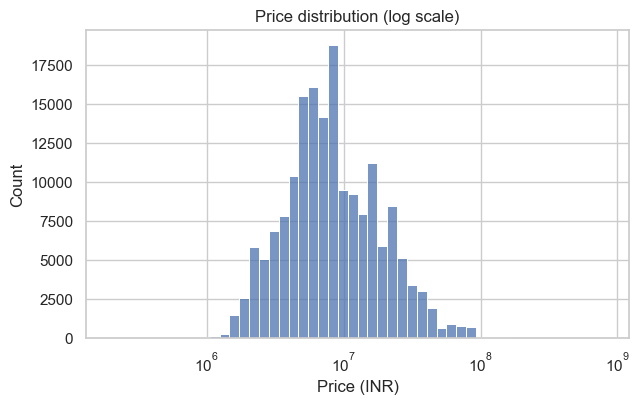

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(df["price_clean"], log_scale=True, bins=50)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (INR)")
plt.show()

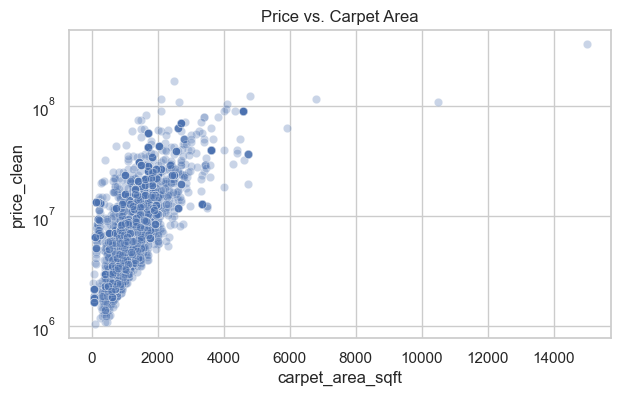

In [ ]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x="carpet_area_sqft", y="price_clean", data=df.sample(min(len(df), 5000), random_state=42), alpha=0.3)
plt.yscale("log")
plt.title("Price vs. Carpet Area")
plt.show()

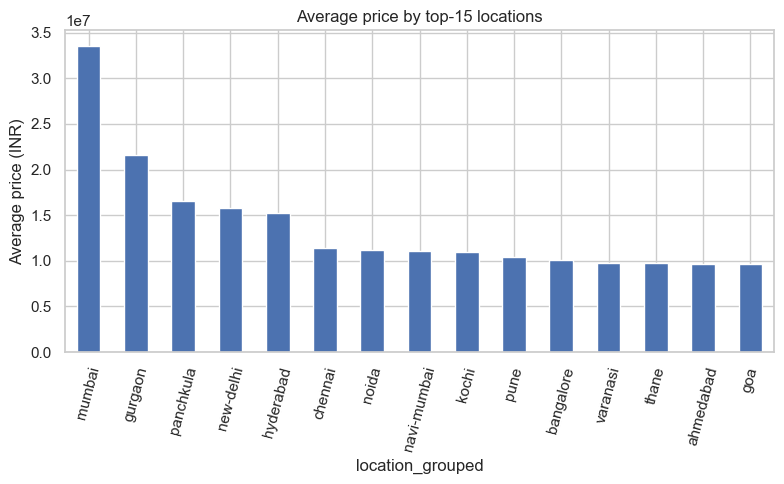

In [ ]:
top_locations_plot = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
top_locations_plot.plot(kind="bar")
plt.title("Average price by top-15 locations")
plt.ylabel("Average price (INR)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

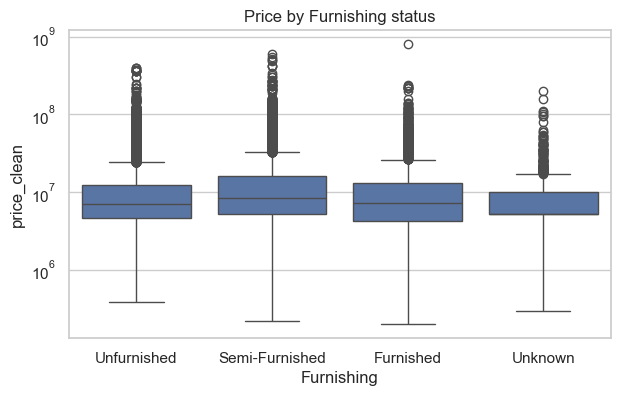

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Furnishing", y="price_clean", data=df)
plt.yscale("log")
plt.title("Price by Furnishing status")
plt.show()

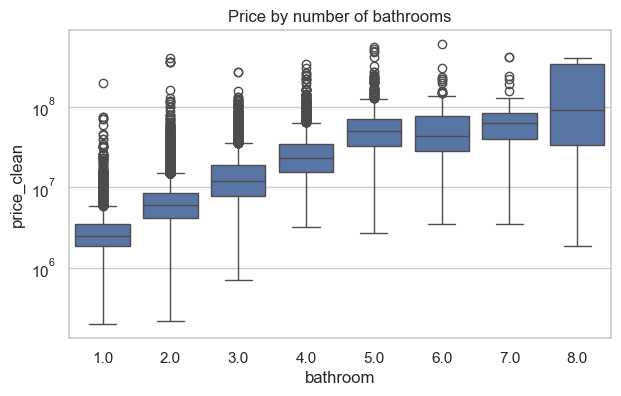

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="bathroom", y="price_clean", data=df[df["bathroom"] <= 8])
plt.yscale("log")
plt.title("Price by number of bathrooms")
plt.show()

Train

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((139576, 9), (34895, 9))

In [20]:
models = {
    "LinearRegression": Pipeline([("prep", preprocessor), ("reg", LinearRegression())]),
    "RandomForest": Pipeline([("prep", preprocessor), ("reg", RandomForestRegressor(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1))]),
    "GradientBoosting": Pipeline([("prep", preprocessor), ("reg", GradientBoostingRegressor(random_state=42, n_estimators=100, max_depth=3))]),
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
print("All models trained.")

All models trained.


Evaluate

In [21]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

results = []
for name, pipe in models.items():
    pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,model,MAE,RMSE,R2
1,RandomForest,1.100189e+06,5.279000e+06,0.850756
2,GradientBoosting,2.984954e+06,6.478526e+06,0.775226
0,LinearRegression,4.532594e+06,8.383117e+06,0.623640


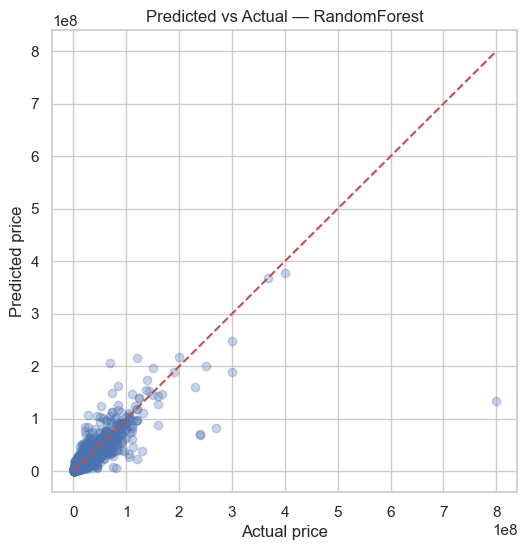

'RandomForest'

In [22]:
best_name = results_df.iloc[0]["model"]
best_model = models[best_name]
pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.3)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs Actual — {best_name}")
plt.show()
best_name

**Model comparison & conclusion:**

On the held-out test set (~35,000 listings):

| Model | MAE (INR) | RMSE (INR) | R² |
|---|---|---|---|
| LinearRegression | ~4,532,608 | ~8,383,120 | 0.624 |
| **RandomForest** | **~1,100,189** | **~5,279,000** | **0.851** |
| GradientBoosting | ~2,984,954 | ~6,478,526 | 0.775 |

**RandomForest wins** by a clear margin on every metric: it roughly quarters the linear
model's MAE and pushes R² from 0.62 to 0.85. This makes sense -- price depends on non-linear
interactions between area, location, and furnishing that a linear model can't capture, while a
forest of trees can. GradientBoosting (default settings) does better than linear regression but
worse than the forest here; with more tuning (learning rate, depth, more estimators) it could
likely close the gap, but RandomForest is the strongest model out of the box and is the one
exported below.


In [ ]:
from sklearn.model_selection import cross_val_score

sample_idx = X.sample(n=min(20000, len(X)), random_state=42).index
cv_scores = cross_val_score(best_model, X.loc[sample_idx], y.loc[sample_idx], cv=5, scoring="r2")
cv_scores, cv_scores.mean()

Export Model

In [ ]:
import joblib

joblib.dump(best_model, "house_price.pkl", compress=3)

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [6999972.25429818]


In [ ]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))
print("Saved locations.json")

Saved locations.json


In [ ]:
import sklearn
print("scikit-learn version used for training:", sklearn.__version__)
print("--> pin this exact version in backend/requirements.txt")

scikit-learn version used for training: 1.5.2
--> pin this exact version in backend/requirements.txt
